In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import yaml
import pandas as pd

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

print(train_dataset[0])

{'story_id': '3920', 'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA717750>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA7179D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA771E00>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA772190>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA772520>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA772650>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA772780>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA7728B0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA7729E0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA772B10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x1A0FA772C40>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 

In [4]:
texts = []
labels = []

def process_dataset(dataset):
    for sample in dataset:
        story = sample["story"]  # list of strings

        for i, sentence in enumerate(story[:5]):  # each is already text
            texts.append(sentence)
            labels.append(i + 1)

process_dataset(train_dataset)
process_dataset(test_dataset)

print("Total samples:", len(texts))

Total samples: 20890


In [5]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [6]:
tokenizer = Tokenizer(num_words=config['dataset']['vocab_size'], oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=config['dataset']['max_len'], padding='post')

y = np.array(labels) - 1  # convert 1–5 → 0–4

In [7]:
print("Dataset size:", len(X))
print("Input shape:", X.shape)

unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Dataset size: 20890
Input shape: (20890, 30)
Class distribution: {np.int64(0): np.int64(4178), np.int64(1): np.int64(4178), np.int64(2): np.int64(4178), np.int64(3): np.int64(4178), np.int64(4): np.int64(4178)}


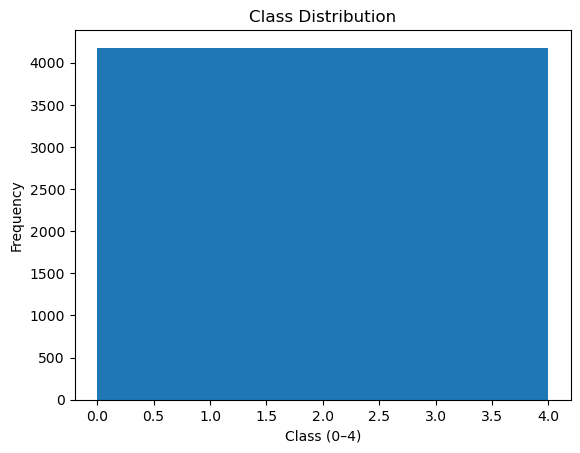

In [8]:
plt.hist(y, bins=5)
plt.title("Class Distribution")
plt.xlabel("Class (0–4)")
plt.ylabel("Frequency")
plt.show()

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=config['training']['validation_split'],
    random_state=42
)

In [10]:
def build_model(lstm_units, dropout):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(
            config['dataset']['vocab_size'],
            config['dataset']['embedding_dim'],
            input_length=config['dataset']['max_len']
        ),
        tf.keras.layers.LSTM(lstm_units),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config['training']['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [11]:
def train_model(name, lstm_units, dropout):
    print(f"\nRunning Experiment: {name}")

    model = build_model(lstm_units, dropout)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config['training']['epochs'],
        batch_size=config['training']['batch_size'],
        verbose=1
    )

    return model, history

In [12]:
experiments = [
    ("baseline", 128, 0.3),
    ("more_units", 256, 0.3),
    ("less_units", 64, 0.3),
    ("high_dropout", 128, 0.5),
    ("no_dropout", 128, 0.0),
]


Running Experiment: baseline


C:\Users\Abhisek\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3360 - loss: 1.2883 - val_accuracy: 0.4102 - val_loss: 1.1199
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.4014 - loss: 1.1151 - val_accuracy: 0.4102 - val_loss: 1.1080
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.3985 - loss: 1.1140 - val_accuracy: 0.4102 - val_loss: 1.1058
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.3977 - loss: 1.1135 - val_accuracy: 0.3978 - val_loss: 1.1100
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.4002 - loss: 1.1135 - val_accuracy: 0.4028 - val_loss: 1.1105
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.3971 - loss: 1.1124 - val_accuracy: 0.4028 - val_loss: 1.1054
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.4239 - loss: 1.0837 - val_accuracy: 0.6103 - val_loss: 0.6649
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.5965 - loss: 0.6665 - 

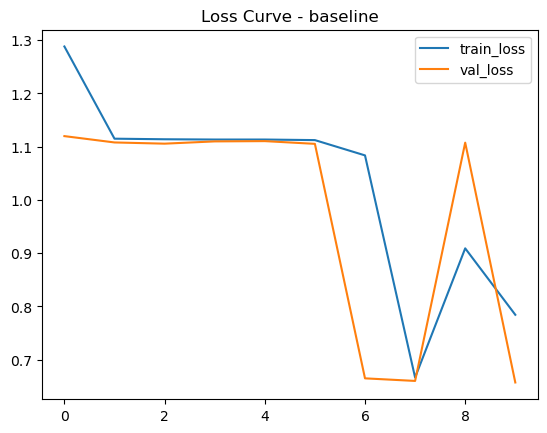


Running Experiment: more_units
Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.3487 - loss: 1.2847 - val_accuracy: 0.3897 - val_loss: 1.1213
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.3978 - loss: 1.1130 - val_accuracy: 0.3897 - val_loss: 1.1179
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.3998 - loss: 1.1102 - val_accuracy: 0.4026 - val_loss: 1.1158
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.3991 - loss: 1.1098 - val_accuracy: 0.4026 - val_loss: 1.1185
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.4019 - loss: 1.0631 - val_accuracy: 0.4026 - val_loss: 0.9444
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.4035 - loss: 0.9415 - val_accuracy: 0.3978 - val_loss: 0.9405
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.4022 - loss: 1.0876 - val_accuracy: 0.4026 - val_loss: 1.1162
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - ac

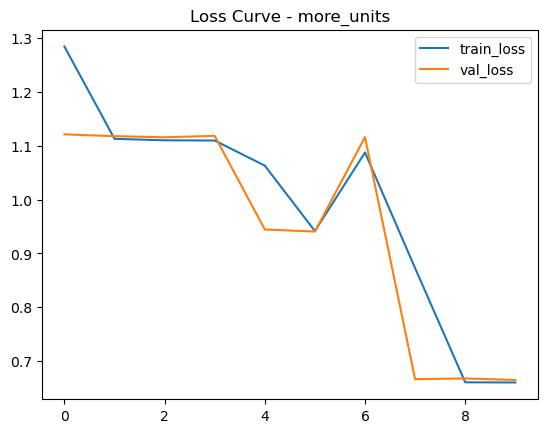


Running Experiment: less_units
Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5588 - loss: 0.8522 - val_accuracy: 0.7925 - val_loss: 0.2969
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7936 - loss: 0.2829 - val_accuracy: 0.7925 - val_loss: 0.2890
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5364 - loss: 0.9065 - val_accuracy: 0.4102 - val_loss: 1.1077
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.3973 - loss: 1.1171 - val_accuracy: 0.6053 - val_loss: 1.0916
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5669 - loss: 0.8057 - val_accuracy: 0.5979 - val_loss: 0.6667
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5972 - loss: 0.6657 - val_accuracy: 0.5979 - val_loss: 0.6630
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.6006 - loss: 0.6632 - val_accuracy: 0.5979 - val_loss: 0.6623
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - ac

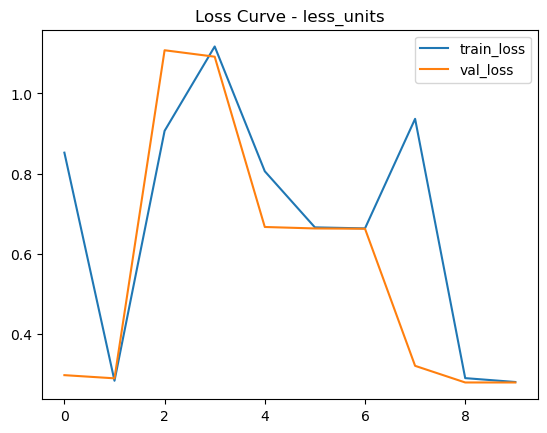


Running Experiment: high_dropout
Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.3477 - loss: 1.2454 - val_accuracy: 0.3973 - val_loss: 1.1069
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3988 - loss: 1.1141 - val_accuracy: 0.3973 - val_loss: 1.1116
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.3998 - loss: 1.1132 - val_accuracy: 0.4028 - val_loss: 1.1076
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3420 - loss: 1.3431 - val_accuracy: 0.3973 - val_loss: 1.5893
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 676s 1s/step - accuracy: 0.4740 - loss: 1.0745 - val_accuracy: 0.5974 - val_loss: 0.6057
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.5916 - loss: 0.6144 - val_accuracy: 0.5974 - val_loss: 0.5629
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.6031 - loss: 0.5798 - val_accuracy: 0.5924 - val_loss: 0.5607
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - a

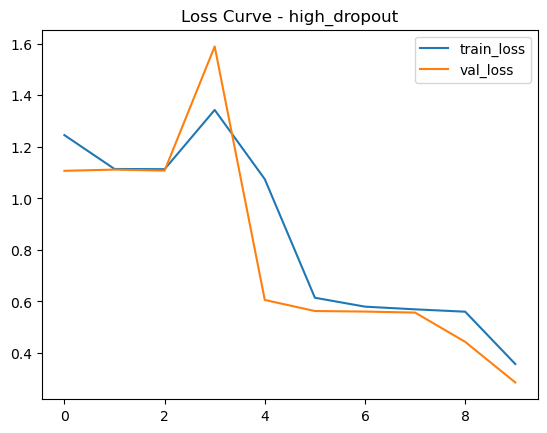


Running Experiment: no_dropout
Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.3609 - loss: 1.2199 - val_accuracy: 0.3952 - val_loss: 1.1145
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3181 - loss: 1.3496 - val_accuracy: 0.1946 - val_loss: 1.6104
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.2073 - loss: 1.6098 - val_accuracy: 0.1951 - val_loss: 1.6097
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1973 - loss: 1.6096 - val_accuracy: 0.1951 - val_loss: 1.6096
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.1951 - loss: 1.6096 - val_accuracy: 0.1951 - val_loss: 1.6095
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.1987 - loss: 1.6095 - val_accuracy: 0.1946 - val_loss: 1.6096
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1987 - loss: 1.6096 - val_accuracy: 0.1946 - val_loss: 1.6095
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - ac

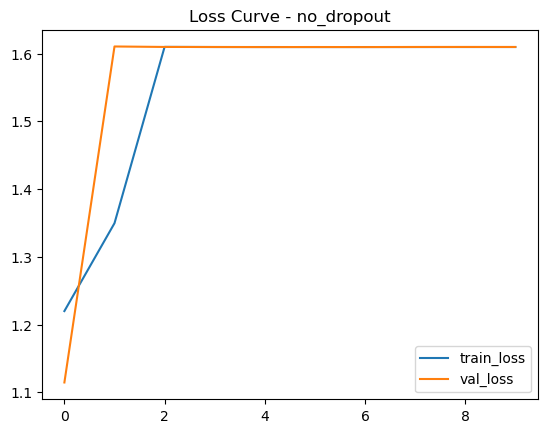

In [13]:
results = []

for name, units, dropout in experiments:
    model, history = train_model(name, units, dropout)

    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    train_acc = model.evaluate(X_train, y_train, verbose=0)[1]
    val_acc = model.evaluate(X_val, y_val, verbose=0)[1]

    results.append({
        "experiment": name,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    })

    # Plot loss curves
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f"Loss Curve - {name}")
    plt.legend()
    plt.show()

In [14]:
df = pd.DataFrame(results)
df

,experiment,train_loss,val_loss,train_acc,val_acc
0,baseline,0.784355,0.657191,0.600527,0.597894
1,more_units,0.659873,0.664554,0.599330,0.602681
2,less_units,0.279838,0.278637,0.798648,0.805409
3,high_dropout,0.357277,0.285627,0.801879,0.792484
4,no_dropout,1.609572,1.609665,0.199976,0.200096


In [15]:
import os
os.makedirs("results/tables", exist_ok=True)

df.to_csv("results/tables/results.csv", index=False)

In [16]:
sample_texts = texts[:5]

sample_seq = tokenizer.texts_to_sequences(sample_texts)
sample_pad = pad_sequences(sample_seq, maxlen=config['dataset']['max_len'])

preds = model.predict(sample_pad)
pred_classes = np.argmax(preds, axis=1)

print("Sample Predictions:")
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Position: {pred_classes[i] + 1}")
    print("------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Sample Predictions:
Text: <
Predicted Position: 2
------
Text: g
Predicted Position: 4
------
Text: d
Predicted Position: 4
------
Text: i
Predicted Position: 2
------
Text:  
Predicted Position: 2
------


In [17]:
val_preds = model.predict(X_val)
val_preds = np.argmax(val_preds, axis=1)

accuracy = np.mean(val_preds == y_val)
print("Validation Accuracy:", accuracy)

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Validation Accuracy: 0.20009573958831978
